# ДЗ 4. Задание 9

In [24]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

In [7]:
records = SeqIO.parse("chr1.fna", "fasta")
record = next(records)
sequence_all = record.seq
sequence = sequence_all[100000:200000]

## Реальные частоты

In [18]:
nucleotides = ['A', 'C', 'G', 'T']
counts_nuc = np.array([sequence.count(n) for n in nucleotides], dtype=float)
P = counts_nuc / counts_nuc.sum()

print(f"Частоты нуклеотидов в последовательности:")
for n, p in zip(nucleotides, P):
    print(f"  {n}: {p:}")

Частоты нуклеотидов в последовательности:
  A: 0.27552933570389526
  C: 0.2419266203329562
  G: 0.23077420397607887
  T: 0.25176983998706964


In [15]:
random_seq = ''.join(np.random.choice(nucleotides, size=len(sequence), p=P))

## Матрицы

**Матрица наблюдаемых частот**

In [25]:
def fr_matrix(seq):
    m = np.zeros((4, 4))
    
    for i in range(len(seq)-1):
        if seq[i] in nucleotides and seq[i+1] in nucleotides:
            a = nucleotides.index(seq[i])
            b = nucleotides.index(seq[i+1])
            m[a, b] += 1
    
    return m

**Матрица ожидаемых частот**

In [30]:
def exp_dinucs(s):
    p = [s.count(n)/len(s) for n in nucleotides]
    return (len(s)-1) * np.outer(p, p), p

## Хи-квадрат

In [31]:
def chi2_test(seq):
    O = fr_matrix(seq)
    E, p = exp_dinucs(seq)

    chi2 = ((O - E)**2 / E).sum()
    p_value = stats.chi2.sf(chi2, df=9)
    
    print(f"p-value = {p_value}")
    if p_value < 0.05:
        print("p-value < 0.05: отвергаем гипотезу независимости ⇒ нужна модель 1-го порядка!")
    else:
        print("p-value >= 0.05: гипотеза независимости не отвергается")
    
    return O, E

**Реальный геном**

In [32]:
O_real, E_real = chi2_test(sequence)

p-value = 0.0
p-value < 0.05: отвергаем гипотезу независимости ⇒ нужна модель 1-го порядка!


**Случайная последовательность**

In [33]:
O_rand, E_rand = chi2_test(random_seq)

p-value = 0.24262326219821426
p-value >= 0.05: гипотеза независимости не отвергается


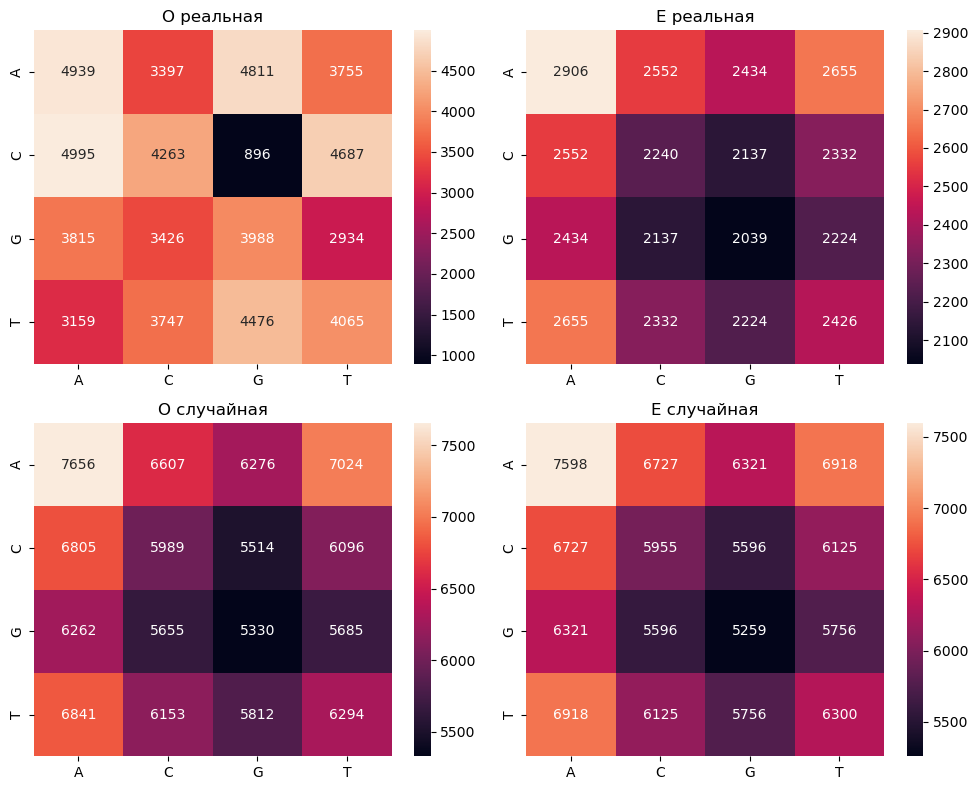

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, mat, title in zip(axes.flat,
                           [O_real, E_real, O_rand, E_rand],
                           ['O реальная', 'E реальная', 'O случайная', 'E случайная']):
    sns.heatmap(mat, annot=True, fmt='.0f', xticklabels=nucleotides,
                yticklabels=nucleotides, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

Для реальной последовательности p-value=0, поэтому гипотеза независимости отвергается: модель 0-го порядка не подходит, нуклеотиды зависят друг от друга (например, частота динуклеотида CG очень сильно отличается от ожидаемой, похоже из-за CpG-островков).

Для случайной последовательности p-value>0.05), поэтому модель 0-го порядка применима — нуклеотиды независимы, что логично для случайно сгенерированной последовательности.

То есть реальный геном не является случайным, его лучше описывает марковская модель 1-го порядка
